# Oscillations in vacuum

The probabilities against baseline and against energy, in vacuum — the figures that `run_testsuite.py` writes to `fig/`, produced here inline instead.

In [1]:
import sys
import os

# Works whether or not the package is installed: the notebooks sit one level
# below the repository root, as the worked examples in test/ do.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import hamiltonians2nu
import hamiltonians3nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Three flavors, against baseline

Fixed energy, varying distance. The fast oscillation is the atmospheric frequency $\Delta m^2_{31}$; the slow envelope is the solar one.

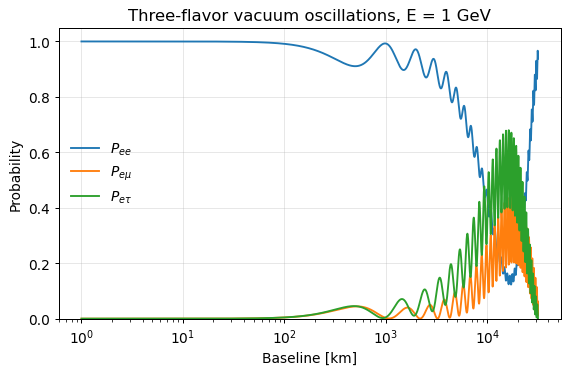

In [2]:
energy = 1.0*GEV
L_km = np.logspace(0.0, 4.5, 3000)
H = np.asarray(H_VAC_3NU)/energy

p = oscprob3nu.probabilities_3nu(H, L_km*KM)

fig, ax = plt.subplots()
ax.semilogx(L_km, p[:, 0], label=r"$P_{ee}$")
ax.semilogx(L_km, p[:, 1], label=r"$P_{e\mu}$")
ax.semilogx(L_km, p[:, 2], label=r"$P_{e\tau}$")
ax.set_xlabel("Baseline [km]")
ax.set_ylabel("Probability")
ax.set_title("Three-flavor vacuum oscillations, "
             "E = 1 GeV")
ax.set_ylim(0.0, 1.05)
ax.legend(loc="center left")
plt.show()

## Three flavors, against energy

Fixed baseline, varying energy. The first oscillation maximum is what a long-baseline experiment is designed to sit on.

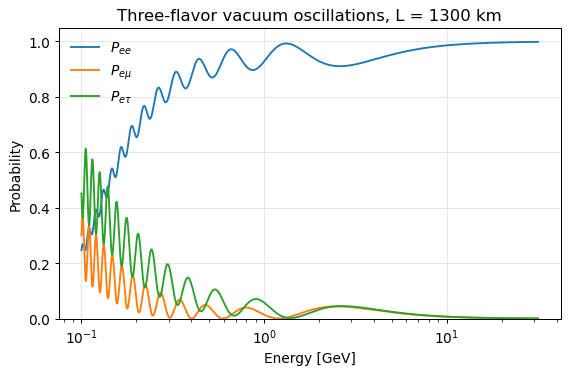

In [3]:
L = 1300.0*KM
E_gev = np.logspace(-1.0, 1.5, 3000)
H_stack = np.asarray(H_VAC_3NU)/(E_gev[:, None, None]*GEV)

p = oscprob3nu.probabilities_3nu(H_stack, L)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p[:, 0], label=r"$P_{ee}$")
ax.semilogx(E_gev, p[:, 1], label=r"$P_{e\mu}$")
ax.semilogx(E_gev, p[:, 2], label=r"$P_{e\tau}$")
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel("Probability")
ax.set_title("Three-flavor vacuum oscillations, L = 1300 km")
ax.set_ylim(0.0, 1.05)
ax.legend(loc="upper left")
plt.show()

Note the shape of the call above: the Hamiltonian was built as a stack of 3000 matrices and passed with a *scalar* baseline. The library broadcasts the two against each other.

## Two flavors

The two-flavor case has the closed form everyone knows, $P_{e\mu} = \sin^2 2\theta \sin^2(\Delta m^2 L / 4E)$. The exact SU(2) result reproduces it, which is one of the checks in the regression suite.

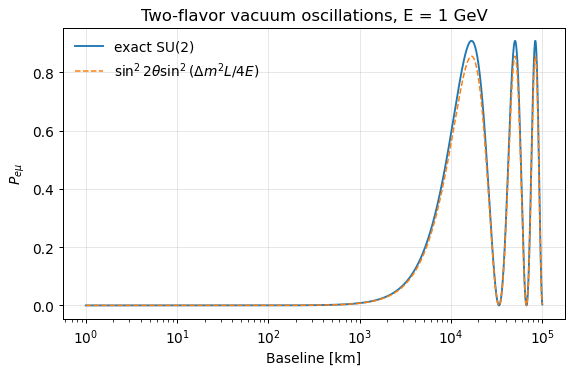

max |exact - textbook| = 5.28e-02


In [4]:
th12 = np.arcsin(np.sqrt(0.310))
H2 = np.asarray(hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    th12, gd.D21_NO_BF))/(1.0*GEV)

L_km = np.logspace(0.0, 5.0, 3000)
p2 = oscprob2nu.probabilities_2nu(H2, L_km*KM)
Pem = p2[:, 1]

analytic = (np.sin(2.0*th12)**2.0
            * np.sin(gd.D21_NO_BF*L_km*KM/(4.0*GEV))**2.0)

fig, ax = plt.subplots()
ax.semilogx(L_km, Pem, label="exact SU(2)")
ax.semilogx(L_km, analytic, "--", lw=1.2,
            label=r"$\sin^2 2\theta \sin^2(\Delta m^2 L/4E)$")
ax.set_xlabel("Baseline [km]")
ax.set_ylabel(r"$P_{e\mu}$")
ax.set_title("Two-flavor vacuum oscillations, E = 1 GeV")
ax.legend(loc="upper left")
plt.show()

print("max |exact - textbook| = %.2e" % np.max(np.abs(Pem-analytic)))